In [62]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns



In [63]:
df=pd.read_csv("messy_dataset_100_rows.csv")


In [64]:
df

,order_id,customer_name,region,product,sales,quantity,order_date
0,1,alice,East,Monitor,641.0,NaN,2024-12-19
1,2,alice,north,Monitor,374.0,3.0,2024-08-18
2,3,Alice,NaN,Phone,NaN,8.0,2024-09-26
3,4,MEHAK,south,Laptop,NaN,8.0,2024-12-09
4,5,Rahul,NaN,Monitor,508.0,5.0,2024-02-26
...,...,...,...,...,...,...,...
95,96,Sara,South,laptop,NaN,NaN,2024-01-20
96,97,NaN,north,Laptop,64.0,5.0,2024/12/31
97,98,NaN,South,Monitor,NaN,6.0,2024-05-31
98,99,Alice,WEST,Monitor,NaN,NaN,2024-11-15


In [65]:
df.isnull().sum()


order_id          0
customer_name     8
region           11
product          16
sales            27
quantity         33
order_date        0
dtype: int64

In [146]:
df['order_date']=pd.to_datetime(df['order_date'],errors="coerce")

In [147]:
df['customer_name'] = df['customer_name'].fillna("Unknown")
df['region'] = df['region'].fillna("Unknown")
df['product'] = df['product'].fillna("Unknown")

In [148]:
df['sales']=df['sales'].fillna(df['sales'].mean())
df['quantity']=df['quantity'].fillna(df['quantity'].mean())

In [150]:
df

,order_id,customer_name,region,product,sales,quantity,order_date,zscore_sales
0,1,alice,East,Monitor,641.000000,5.656716,2024-12-19,5.257102e-01
1,2,alice,north,Monitor,374.000000,3.000000,2024-08-18,-5.100340e-01
2,3,Alice,Unknown,Phone,505.479452,8.000000,2024-09-26,-2.205065e-16
3,4,MEHAK,south,Laptop,505.479452,8.000000,2024-12-09,-2.205065e-16
4,5,Rahul,Unknown,Monitor,508.000000,5.000000,2024-02-26,9.777689e-03
...,...,...,...,...,...,...,...,...
95,96,Sara,South,laptop,505.479452,5.656716,2024-01-20,-2.205065e-16
96,97,Unknown,north,Laptop,64.000000,5.000000,NaT,-1.712583e+00
97,98,Unknown,South,Monitor,505.479452,6.000000,2024-05-31,-2.205065e-16
98,99,Alice,WEST,Monitor,505.479452,5.656716,2024-11-15,-2.205065e-16


In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       100 non-null    int64  
 1   customer_name  100 non-null    object 
 2   region         100 non-null    object 
 3   product        100 non-null    object 
 4   sales          100 non-null    float64
 5   quantity       100 non-null    float64
 6   order_date     100 non-null    object 
dtypes: float64(2), int64(1), object(4)
memory usage: 5.6+ KB


In [77]:
df.describe()

,order_id,sales,quantity
count,100.000000,100.000000,100.000000
mean,50.500000,505.479452,5.656716
std,29.011492,259.084328,2.072193
min,1.000000,62.000000,1.000000
25%,25.750000,323.750000,4.000000
50%,50.500000,505.479452,5.656716
75%,75.250000,705.000000,7.000000
max,100.000000,982.000000,10.000000


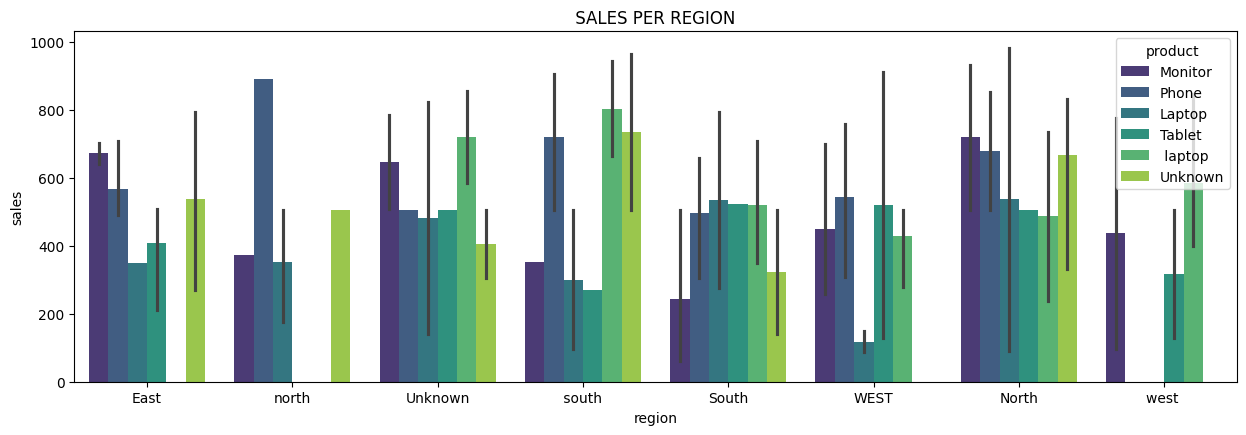

In [105]:
plt.figure(figsize=(15,4.55))
plt.title(" SALES PER REGION ")
sns.barplot(df,x=df['region'],y=df['sales'],hue=df['product'], palette="viridis")
plt.show()

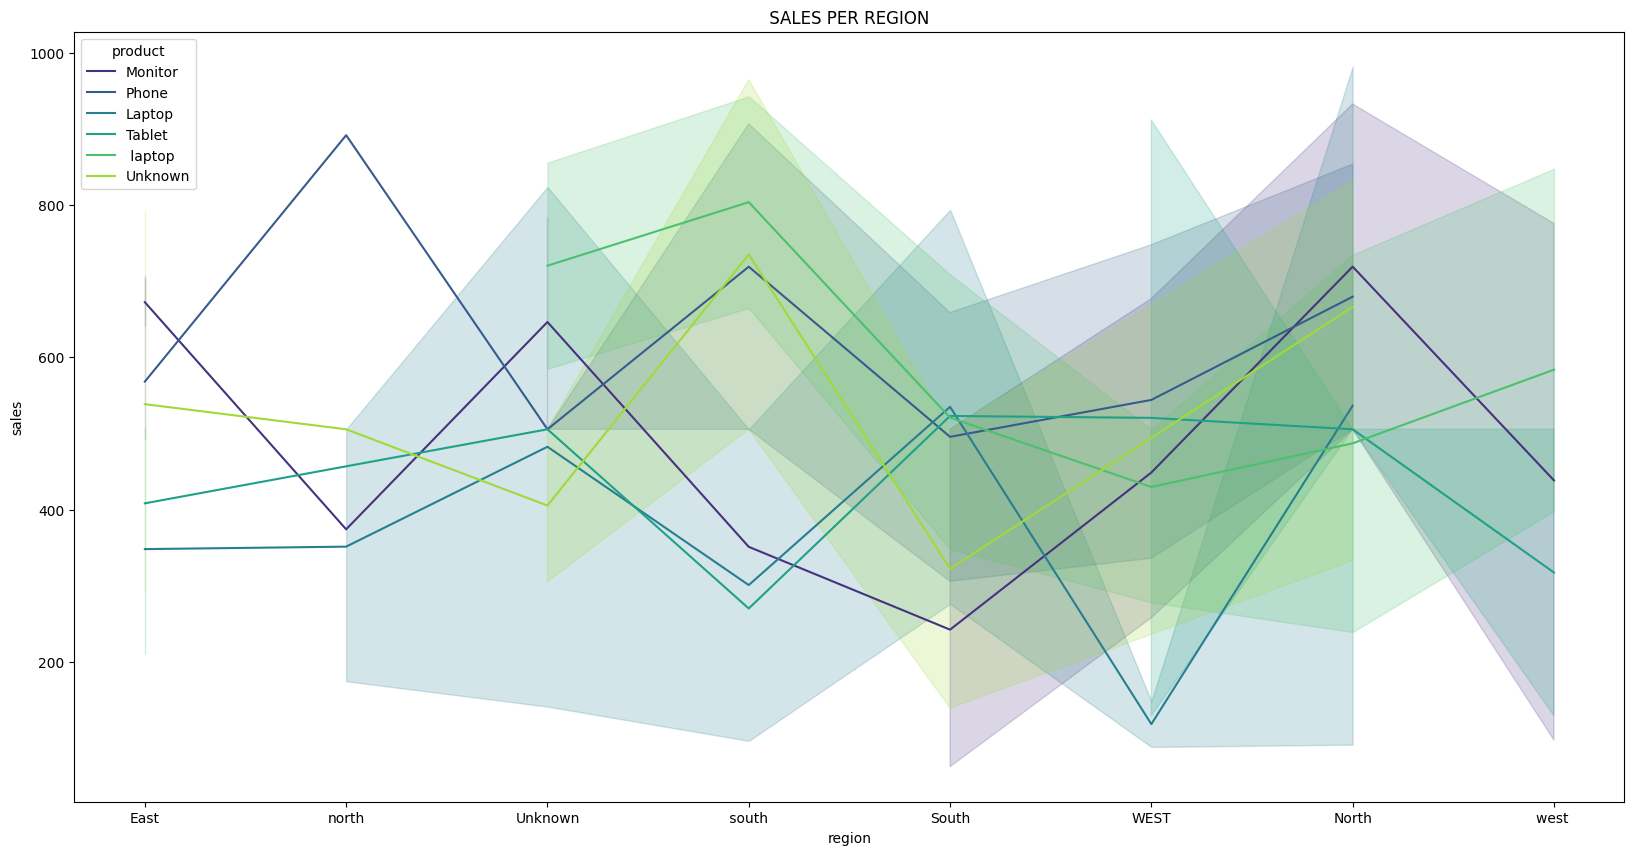

In [106]:
plt.figure(figsize=(20,10))
plt.title(" SALES PER REGION ")

sns.lineplot(df,x=df['region'],y=df['sales'],hue=df['product'], palette="viridis")
plt.show()

In [ ]:
plt.figure(figsize=(20,10))
plt.title(" SALES PER REGION ")
plt.x
sns.barplot(df,x=df['region'],y=df['sales'],hue=df['product'], palette="viridis")
plt.show()

<Axes: title={'center': ' SALES PER REGION '}, xlabel='customer_name', ylabel='Count'>

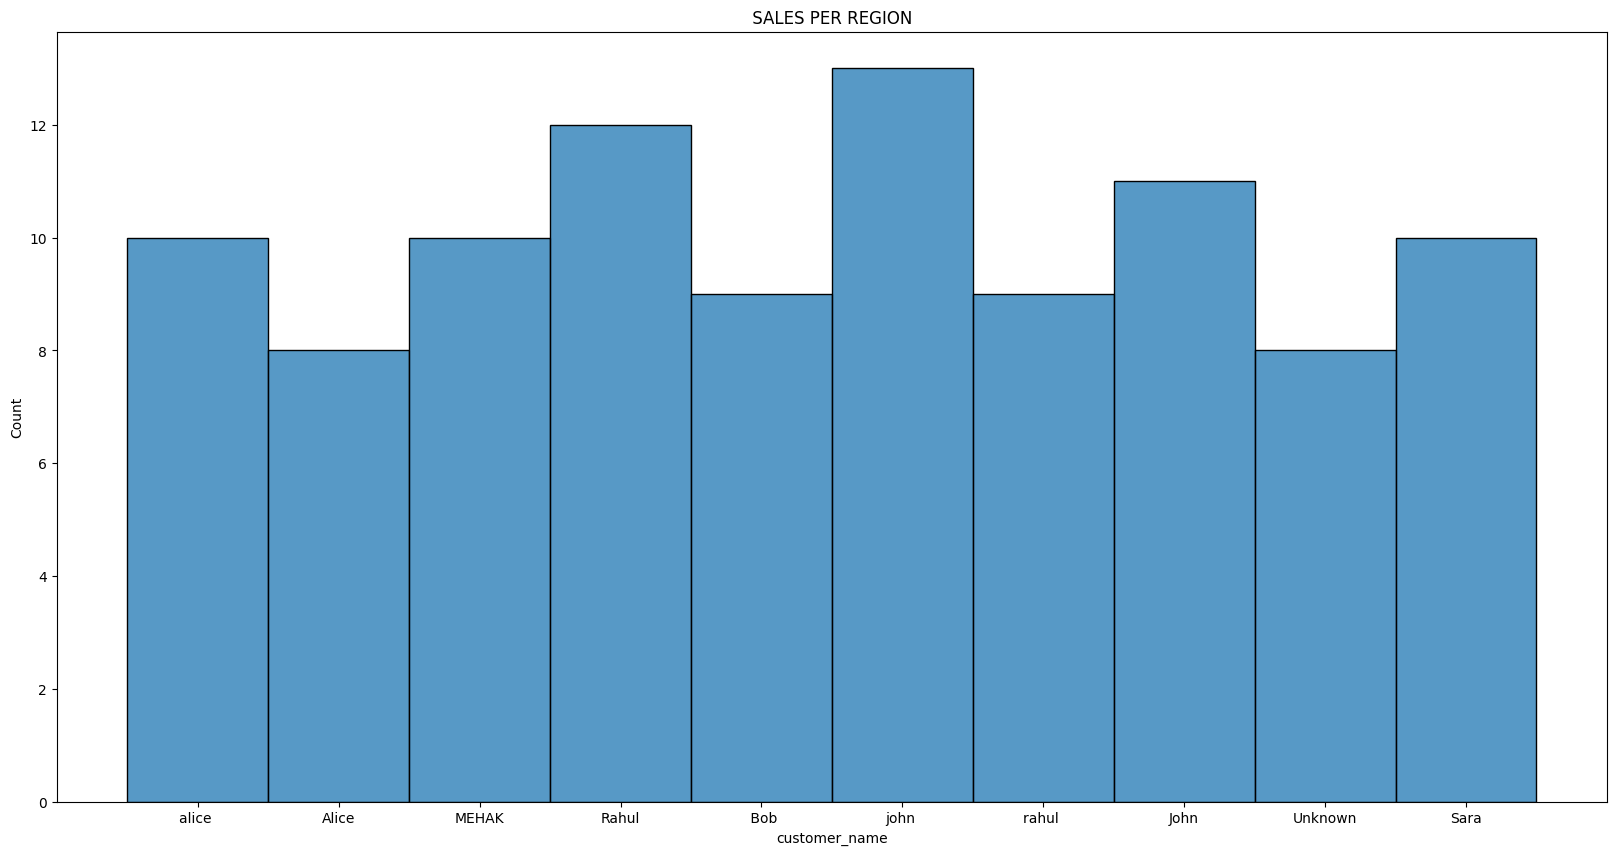

In [111]:
plt.figure(figsize=(20,10))
plt.title(" SALES PER REGION ")
sns.histplot(data=df, x=df['customer_name'], bins=10)

<Axes: xlabel='sales'>

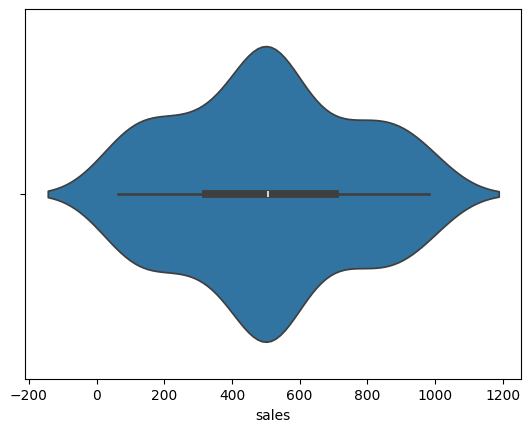

In [113]:
sns.violinplot(data=df,x=df['sales'])

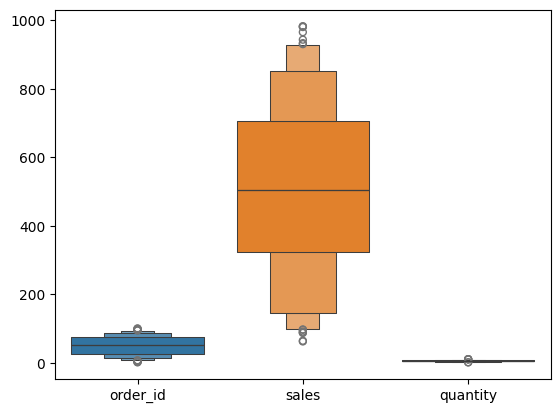

In [119]:
sns.boxenplot(data=df[["order_id","customer_name","region","product","sales","quantity"]])
plt.show()

In [123]:
from scipy .stats import zscore

df['zscore_sales']=zscore(df['sales'])

outliers=df[df['zscore_sales'].abs()>3]
print(outliers)

Empty DataFrame
Columns: [order_id, customer_name, region, product, sales, quantity, order_date, zscore_sales]
Index: []


<Axes: xlabel='sales', ylabel='Count'>

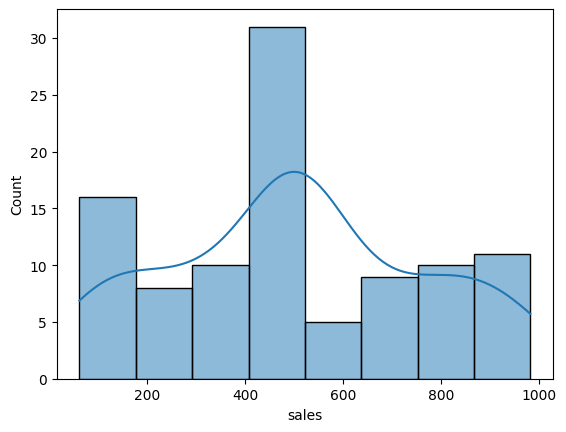

In [125]:
sns.histplot(data=df, x=df['sales'],kde=True)

In [127]:
q1=df['sales'].quantile(0.25)
q3=df['sales'].quantile(0.75)

IQR=q3-q1
lower_bound=q1-1.5*IQR
upper_bound=q3+1.5*IQR


outliers_iqr=df[(df['sales']<lower_bound )| (df['sales']>upper_bound)]
print(outliers_iqr)

Empty DataFrame
Columns: [order_id, customer_name, region, product, sales, quantity, order_date, zscore_sales]
Index: []


In [128]:
df

,order_id,customer_name,region,product,sales,quantity,order_date,zscore_sales
0,1,alice,East,Monitor,641.000000,5.656716,2024-12-19 00:00:00,5.257102e-01
1,2,alice,north,Monitor,374.000000,3.000000,2024-08-18 00:00:00,-5.100340e-01
2,3,Alice,Unknown,Phone,505.479452,8.000000,2024-09-26 00:00:00,-2.205065e-16
3,4,MEHAK,south,Laptop,505.479452,8.000000,2024-12-09 00:00:00,-2.205065e-16
4,5,Rahul,Unknown,Monitor,508.000000,5.000000,2024-02-26 00:00:00,9.777689e-03
...,...,...,...,...,...,...,...,...
95,96,Sara,South,laptop,505.479452,5.656716,2024-01-20 00:00:00,-2.205065e-16
96,97,Unknown,north,Laptop,64.000000,5.000000,unkown,-1.712583e+00
97,98,Unknown,South,Monitor,505.479452,6.000000,2024-05-31 00:00:00,-2.205065e-16
98,99,Alice,WEST,Monitor,505.479452,5.656716,2024-11-15 00:00:00,-2.205065e-16


In [134]:
df_1=df[(df['quantity']==4) & (df['product']=="Monitor")]

In [136]:
df_1.reset_index()

,index,order_id,customer_name,region,product,sales,quantity,order_date,zscore_sales
0,15,16,MEHAK,Unknown,Monitor,785.000000,4.0,unkown,1.084314e+00
1,30,31,alice,WEST,Monitor,236.000000,4.0,2024-11-09 00:00:00,-1.045362e+00
2,65,66,Alice,WEST,Monitor,505.479452,4.0,unkown,-2.205065e-16
3,81,82,john,west,Monitor,776.000000,4.0,unkown,1.049401e+00


In [137]:
df_1

,order_id,customer_name,region,product,sales,quantity,order_date,zscore_sales
15,16,MEHAK,Unknown,Monitor,785.000000,4.0,unkown,1.084314e+00
30,31,alice,WEST,Monitor,236.000000,4.0,2024-11-09 00:00:00,-1.045362e+00
65,66,Alice,WEST,Monitor,505.479452,4.0,unkown,-2.205065e-16
81,82,john,west,Monitor,776.000000,4.0,unkown,1.049401e+00


In [153]:
df['year']=df['order_date'].dt.year

In [154]:
df

,order_id,customer_name,region,product,sales,quantity,order_date,zscore_sales,year
0,1,alice,East,Monitor,641.000000,5.656716,2024-12-19,5.257102e-01,2024.0
1,2,alice,north,Monitor,374.000000,3.000000,2024-08-18,-5.100340e-01,2024.0
2,3,Alice,Unknown,Phone,505.479452,8.000000,2024-09-26,-2.205065e-16,2024.0
3,4,MEHAK,south,Laptop,505.479452,8.000000,2024-12-09,-2.205065e-16,2024.0
4,5,Rahul,Unknown,Monitor,508.000000,5.000000,2024-02-26,9.777689e-03,2024.0
...,...,...,...,...,...,...,...,...,...
95,96,Sara,South,laptop,505.479452,5.656716,2024-01-20,-2.205065e-16,2024.0
96,97,Unknown,north,Laptop,64.000000,5.000000,NaT,-1.712583e+00,NaN
97,98,Unknown,South,Monitor,505.479452,6.000000,2024-05-31,-2.205065e-16,2024.0
98,99,Alice,WEST,Monitor,505.479452,5.656716,2024-11-15,-2.205065e-16,2024.0


In [158]:
df_2=df.groupby(['region',"product"])['sales'].sum().reset_index()

<Axes: xlabel='region', ylabel='sales'>

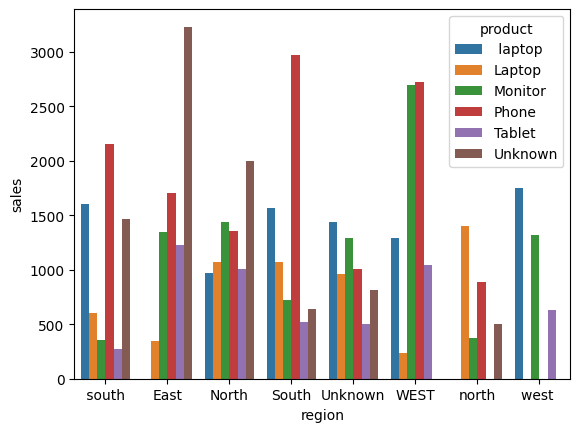

In [162]:
sns.barplot(data=df_2,x=df_2['region'],y=df_2['sales'],hue=df_2["product"])

In [163]:
plt.savefig("mehak.png")

<Figure size 640x480 with 0 Axes>